# LAB 2 - Notebook bài mẫu: Chuẩn bị dữ liệu IoT cho AI, train baseline và chuẩn bị deploy model

**Case mẫu:** Smart Classroom Occupancy & Air Quality  
**Dataset chính:** UCI Occupancy Detection  
**Mục tiêu notebook:** chạy trọn vẹn luồng `telemetry → clean data → feature dataset → baseline model → decision log → model artifact`.

> Sau notebook này, sinh viên sẽ dùng file `models/occupancy_baseline.joblib` để deploy bằng FastAPI ở bước tiếp theo.

## 0. Sinh viên cần hiểu project này trước khi chạy

Trong Lab 2, ta không lập trình lại ESP/MQTT/dashboard cơ bản. Ta giả định dữ liệu telemetry đã được hệ thống IoT ghi nhận.

Project mẫu gồm các phần chính:

| Thành phần | Vai trò |
|---|---|
| `data/` | Chứa dữ liệu public hoặc dữ liệu fallback cùng schema |
| `notebooks/` | Notebook xử lý dữ liệu và train baseline |
| `src/data_utils.py` | Các hàm dùng chung: tải data, clean, train, decision |
| `src/app.py` | FastAPI dùng để deploy model sau khi train |
| `models/` | Chứa file model `.joblib` |
| `outputs/` | Chứa metric, decision log và biểu đồ kiểm tra |

Cách đọc project: trước tiên chạy notebook này, sau đó chạy API trong terminal.

## 1. Import thư viện và thiết lập đường dẫn

Cell này giúp notebook nhận ra thư mục gốc của project, kể cả khi mở notebook từ thư mục `notebooks/`.

In [2]:
from pathlib import Path
import sys
import json

# Đưa thư mục project vào sys.path để import được src/*
PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name == "notebooks":
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

print("PROJECT_ROOT =", PROJECT_ROOT)

PROJECT_ROOT = d:\Ki3_nam3\AIot\lab2_aiot_public_dataset_deploy 2\lab2_aiot_public_dataset_deploy 2


## 2. Tải hoặc nạp dataset

Notebook ưu tiên dataset công khai **UCI Occupancy Detection**.  
Nếu máy không có Internet, project sẽ dùng file fallback cùng schema để sinh viên vẫn chạy được toàn bộ pipeline.

Dữ liệu gốc có các trường chính:
- `date`
- `Temperature`
- `Humidity`
- `Light`
- `CO2`
- `HumidityRatio`
- `Occupancy`

In [3]:
from src.data_utils import ensure_dataset, check_schema

raw_df, dataset_status = ensure_dataset(prefer_public=True)

print("Dataset source:", dataset_status["dataset_source"])
for msg in dataset_status["messages"]:
    print("-", msg)

print("\nShape:", raw_df.shape)
display(raw_df.head())

Dataset source: UCI Occupancy Detection public dataset via LuisM78 GitHub mirror
- OK: datatraining.txt already exists.
- OK: datatest.txt already exists.
- OK: datatest2.txt already exists.

Shape: (20560, 8)


,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy,source_split
0,2015-02-04 17:51:00,23.18,27.2720,426.0,721.25,0.004793,1,train
1,2015-02-04 17:51:59,23.15,27.2675,429.5,714.00,0.004783,1,train
2,2015-02-04 17:53:00,23.15,27.2450,426.0,713.50,0.004779,1,train
3,2015-02-04 17:54:00,23.15,27.2000,426.0,708.25,0.004772,1,train
4,2015-02-04 17:55:00,23.10,27.2000,426.0,704.50,0.004757,1,train


## 3. Kiểm tra schema telemetry

Ở hệ thống AIoT thật, bước này giúp phát hiện lỗi trước khi train model:
- thiếu cột;
- sai kiểu dữ liệu;
- duplicate;
- timestamp không parse được;
- sensor value nằm ngoài miền hợp lý.

In [4]:
schema_report = check_schema(raw_df)
print(json.dumps(schema_report, ensure_ascii=False, indent=2))

{
  "required_columns": [
    "date",
    "Temperature",
    "Humidity",
    "Light",
    "CO2",
    "HumidityRatio",
    "Occupancy"
  ],
  "missing_columns": [],
  "duplicated_rows": 0,
  "n_rows": 20560,
  "n_columns": 8
}


## 4. Làm sạch dữ liệu IoT

Các lỗi xử lý trong bài mẫu:
- Timestamp sai hoặc rỗng.
- Dòng trùng lặp.
- Sensor outlier: CO2 quá cao/vô lý, humidity > 100%, temperature quá cao...
- Missing value trong sensor.

Chiến lược xử lý:
- Parse `date` thành `timestamp`.
- Xóa duplicate.
- Đưa outlier về `NaN`.
- Nội suy tuyến tính theo thời gian, sau đó `ffill/bfill`.

In [5]:
from src.data_utils import clean_iot_data

clean_df, cleaning_report = clean_iot_data(raw_df)

print(json.dumps(cleaning_report, ensure_ascii=False, indent=2))
print("\nClean shape:", clean_df.shape)
display(clean_df.head())

clean_df.to_csv(PROJECT_ROOT / "data" / "telemetry_clean.csv", index=False)

{
  "before_rows": 20560,
  "after_rows": 20560,
  "removed_rows": 0,
  "bad_timestamp_rows": 0,
  "duplicate_rows": 0,
  "duplicate_timestamps": 0,
  "outlier_counts": {
    "Temperature": 0,
    "Humidity": 0,
    "Light": 0,
    "CO2": 0,
    "HumidityRatio": 0
  },
  "missing_before_fill": {
    "Temperature": 0,
    "Humidity": 0,
    "Light": 0,
    "CO2": 0,
    "HumidityRatio": 0
  }
}

Clean shape: (20560, 9)


,date,Temperature,Humidity,Light,CO2,HumidityRatio,Occupancy,source_split,timestamp
0,2015-02-02 14:19:00,23.7000,26.272,585.200000,749.200000,0.004764,1,test1,2015-02-02 14:19:00
1,2015-02-02 14:19:59,23.7180,26.290,578.400000,760.400000,0.004773,1,test1,2015-02-02 14:19:59
2,2015-02-02 14:21:00,23.7300,26.230,572.666667,769.666667,0.004765,1,test1,2015-02-02 14:21:00
3,2015-02-02 14:22:00,23.7225,26.125,493.750000,774.750000,0.004744,1,test1,2015-02-02 14:22:00
4,2015-02-02 14:23:00,23.7540,26.200,488.600000,779.000000,0.004767,1,test1,2015-02-02 14:23:00


## 5. Tạo feature dataset

Feature trong bài mẫu gồm:
- Feature gốc: `Temperature`, `Humidity`, `Light`, `CO2`, `HumidityRatio`.
- Feature thời gian: `hour`, `dayofweek`.
- Feature giải thích/decision log: rolling mean, delta.

Lưu ý: API deploy ở Lab 2 chỉ dùng feature đơn giản để sinh viên dễ hiểu input/output. Các feature rolling sẽ học sâu hơn ở các lab tiếp theo.

In [6]:
from src.data_utils import create_features

feature_df = create_features(clean_df)
feature_df.to_csv(PROJECT_ROOT / "data" / "feature_dataset.csv", index=False)

display(feature_df[[
    "timestamp", "Temperature", "Humidity", "Light", "CO2", "HumidityRatio",
    "hour", "dayofweek", "co2_rolling_mean_10", "co2_delta", "Occupancy"
]].head())

,timestamp,Temperature,Humidity,Light,CO2,HumidityRatio,hour,dayofweek,co2_rolling_mean_10,co2_delta,Occupancy
0,2015-02-02 14:19:00,23.7000,26.272,585.200000,749.200000,0.004764,14,0,749.200000,0.000000,1
1,2015-02-02 14:19:59,23.7180,26.290,578.400000,760.400000,0.004773,14,0,754.800000,11.200000,1
2,2015-02-02 14:21:00,23.7300,26.230,572.666667,769.666667,0.004765,14,0,759.755556,9.266667,1
3,2015-02-02 14:22:00,23.7225,26.125,493.750000,774.750000,0.004744,14,0,763.504167,5.083333,1
4,2015-02-02 14:23:00,23.7540,26.200,488.600000,779.000000,0.004767,14,0,766.603333,4.250000,1


## 6. Chia train/test theo thời gian

Với dữ liệu IoT dạng time-series, không nên chia ngẫu nhiên như nhiều bài ML cơ bản, vì dễ rò rỉ thông tin tương lai vào quá khứ.

Cách chia ở bài mẫu:
- 75% dữ liệu đầu theo thời gian → train
- 25% dữ liệu sau theo thời gian → test

In [7]:
from src.data_utils import time_train_test_split

train_df, test_df = time_train_test_split(feature_df, test_ratio=0.25)

print("Train:", train_df["timestamp"].min(), "→", train_df["timestamp"].max(), train_df.shape)
print("Test :", test_df["timestamp"].min(), "→", test_df["timestamp"].max(), test_df.shape)
print("\nTrain Occupancy distribution:")
display(train_df["Occupancy"].value_counts(normalize=True).rename("ratio"))

Train: 2015-02-02 14:19:00 → 2015-02-14 19:38:59 (15420, 14)
Test : 2015-02-14 19:40:00 → 2015-02-18 09:19:00 (5140, 14)

Train Occupancy distribution:


Occupancy
0    0.7631
1    0.2369
Name: ratio, dtype: float64

## 7. Train AI baseline đầu tiên

Baseline model: **Logistic Regression**.

Vì sao chọn Logistic Regression?
- Dễ giải thích cho sinh viên mới deploy model.
- Chạy nhanh, ít lỗi thư viện.
- Có `predict_proba` để biến output thành xác suất.
- Phù hợp làm baseline trước khi dùng model phức tạp hơn.

Input model:
`Temperature, Humidity, Light, CO2, HumidityRatio, hour, dayofweek`

Output model:
`occupancy_probability`, `predicted_occupancy`

In [8]:
from src.data_utils import API_FEATURES, train_baseline_model, evaluate_model

model = train_baseline_model(train_df)
metrics = evaluate_model(model, test_df)

print("Feature dùng cho model:", API_FEATURES)
print(json.dumps(metrics, ensure_ascii=False, indent=2))

Feature dùng cho model: ['Temperature', 'Humidity', 'Light', 'CO2', 'HumidityRatio', 'hour', 'dayofweek']
{
  "accuracy": 0.9943579766536965,
  "precision": 0.9750889679715302,
  "recall": 0.9990884229717412,
  "f1": 0.9869428185502026,
  "roc_auc": 0.9988282300727526,
  "confusion_matrix": [
    [
      4015,
      28
    ],
    [
      1,
      1096
    ]
  ]
}


## 8. AI baseline phụ: anomaly score bằng Z-score

Lab 2 chưa đi sâu anomaly detection, vì Lab 3 sẽ học kỹ hơn.  
Tuy nhiên bài mẫu vẫn tạo `anomaly_score` để decision layer biết khi nào không nên tự động điều khiển.

Ý tưởng:
- Tính mean/std trên tập train.
- Với một telemetry mới, tính Z-score từng sensor.
- Lấy max Z-score làm `anomaly_score`.
- Nếu `anomaly_score >= 3`: đánh dấu `is_anomaly = True`.

In [9]:
from src.data_utils import compute_train_stats, compute_anomaly_score, RAW_FEATURES

train_stats = compute_train_stats(train_df)
sample_scores = compute_anomaly_score(test_df[RAW_FEATURES].head(10), train_stats)

print("Train stats:")
print(json.dumps(train_stats, ensure_ascii=False, indent=2)[:1200])
print("\nAnomaly score 10 dòng đầu tập test:")
print(sample_scores)

Train stats:
{
  "Temperature": {
    "mean": 20.92662041025878,
    "std": 1.1418782731947776
  },
  "Humidity": {
    "mean": 26.723268508739423,
    "std": 5.187454429504924
  },
  "Light": {
    "mean": 137.154609968501,
    "std": 218.1779209092372
  },
  "CO2": {
    "mean": 618.80790647582,
    "std": 270.3296748544475
  },
  "HumidityRatio": {
    "mean": 0.004089767214199799,
    "std": 0.0007963832662009448
  }
}

Anomaly score 10 dòng đầu tập test:
[1.67263763 1.67263763 1.66203513 1.67263763 1.67263763 1.67263763
 1.67263763 1.67263763 1.67263763 1.67263763]


## 9. Sinh decision log

Decision log là phần giúp Lab 2 không dừng ở train/test model.

Mỗi dòng decision log cho thấy:
- dữ liệu đầu vào;
- output AI;
- cờ bất thường;
- quyết định/cảnh báo;
- gợi ý command;
- safety note.

Đây chính là cầu nối sang Dashboard/Command/Feedback của hệ thống AIoT.

In [10]:
from src.data_utils import make_decision_log

decision_log = make_decision_log(model, test_df, train_stats, n_rows=200)
decision_log.to_csv(PROJECT_ROOT / "outputs" / "decision_log.csv", index=False)

display(decision_log.head(10))
print("Decision log shape:", decision_log.shape)
print("\nDecision counts:")
display(decision_log["decision"].value_counts())

,timestamp,Temperature,Humidity,Light,CO2,HumidityRatio,occupancy_probability,actual_occupancy,predicted_occupancy,anomaly_score,is_anomaly,decision,command_hint,safety_note
0,2015-02-18 06:00:00,20.790,26.390,0.0,1486.000000,0.004004,0.0143,0,0,3.2079,True,CHECK_SENSOR_OR_DATA,NO_AUTO_CONTROL,Dữ liệu có dấu hiệu bất thường; không gửi lệnh...
1,2015-02-18 06:01:00,20.790,26.445,0.0,1489.000000,0.004012,0.0145,0,0,3.2190,True,CHECK_SENSOR_OR_DATA,NO_AUTO_CONTROL,Dữ liệu có dấu hiệu bất thường; không gửi lệnh...
2,2015-02-18 06:02:00,20.790,26.500,0.0,1492.000000,0.004020,0.0146,0,0,3.2301,True,CHECK_SENSOR_OR_DATA,NO_AUTO_CONTROL,Dữ liệu có dấu hiệu bất thường; không gửi lệnh...
3,2015-02-18 06:03:00,20.790,26.500,0.0,1516.000000,0.004020,0.0157,0,0,3.3189,True,CHECK_SENSOR_OR_DATA,NO_AUTO_CONTROL,Dữ liệu có dấu hiệu bất thường; không gửi lệnh...
4,2015-02-18 06:04:00,20.790,26.500,0.0,1533.000000,0.004020,0.0165,0,0,3.3818,True,CHECK_SENSOR_OR_DATA,NO_AUTO_CONTROL,Dữ liệu có dấu hiệu bất thường; không gửi lệnh...
5,2015-02-18 06:04:59,20.790,26.500,0.0,1552.666667,0.004020,0.0175,0,0,3.4545,True,CHECK_SENSOR_OR_DATA,NO_AUTO_CONTROL,Dữ liệu có dấu hiệu bất thường; không gửi lệnh...
6,2015-02-18 06:06:00,20.745,26.500,0.0,1561.500000,0.004009,0.0188,0,0,3.4872,True,CHECK_SENSOR_OR_DATA,NO_AUTO_CONTROL,Dữ liệu có dấu hiệu bất thường; không gửi lệnh...
7,2015-02-18 06:07:00,20.790,26.500,0.0,1569.500000,0.004020,0.0184,0,0,3.5168,True,CHECK_SENSOR_OR_DATA,NO_AUTO_CONTROL,Dữ liệu có dấu hiệu bất thường; không gửi lệnh...
8,2015-02-18 06:08:00,20.790,26.500,0.0,1563.500000,0.004020,0.0181,0,0,3.4946,True,CHECK_SENSOR_OR_DATA,NO_AUTO_CONTROL,Dữ liệu có dấu hiệu bất thường; không gửi lệnh...
9,2015-02-18 06:08:59,20.790,26.500,0.0,1555.500000,0.004020,0.0177,0,0,3.4650,True,CHECK_SENSOR_OR_DATA,NO_AUTO_CONTROL,Dữ liệu có dấu hiệu bất thường; không gửi lệnh...


Decision log shape: (200, 14)

Decision counts:


decision
CHECK_SENSOR_OR_DATA      152
ROOM_EMPTY_SAVE_ENERGY     48
Name: count, dtype: int64

## 10. Lưu model và artifact để deploy

Sau khi train, ta không copy code notebook vào API.  
Ta lưu model thành file `.joblib`, sau đó FastAPI sẽ load file này.

Các artifact cần có:
- `models/occupancy_baseline.joblib`
- `outputs/metrics.json`
- `outputs/decision_log.csv`
- `data/feature_dataset.csv`

In [11]:
from src.data_utils import save_artifacts

save_artifacts(
    model=model,
    feature_cols=API_FEATURES,
    train_stats=train_stats,
    metrics=metrics,
    dataset_status=dataset_status
)

print("Saved model:", PROJECT_ROOT / "models" / "occupancy_baseline.joblib")
print("Saved metrics:", PROJECT_ROOT / "outputs" / "metrics.json")
print("Saved decision log:", PROJECT_ROOT / "outputs" / "decision_log.csv")

Saved model: d:\Ki3_nam3\AIot\lab2_aiot_public_dataset_deploy 2\lab2_aiot_public_dataset_deploy 2\models\occupancy_baseline.joblib
Saved metrics: d:\Ki3_nam3\AIot\lab2_aiot_public_dataset_deploy 2\lab2_aiot_public_dataset_deploy 2\outputs\metrics.json
Saved decision log: d:\Ki3_nam3\AIot\lab2_aiot_public_dataset_deploy 2\lab2_aiot_public_dataset_deploy 2\outputs\decision_log.csv


## 11. Vẽ biểu đồ kiểm tra nhanh

Sinh viên cần xem biểu đồ để hiểu model không phải là hộp đen hoàn toàn:
- CO2 theo thời gian.
- Confusion matrix.
- Xác suất occupancy trên tập test.

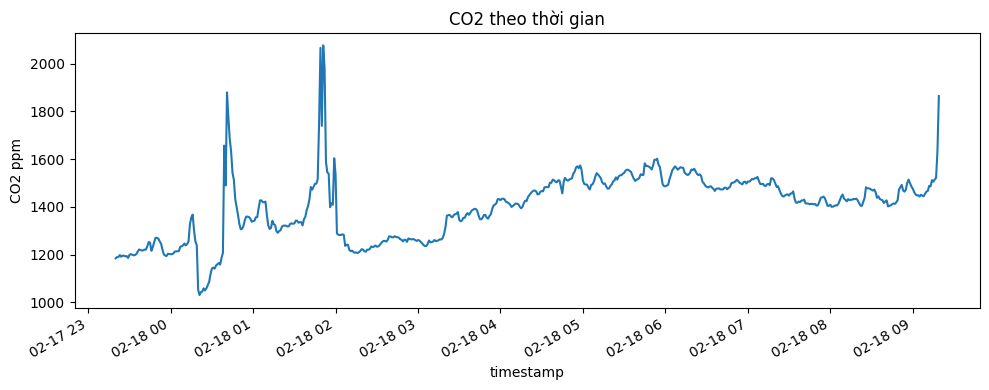

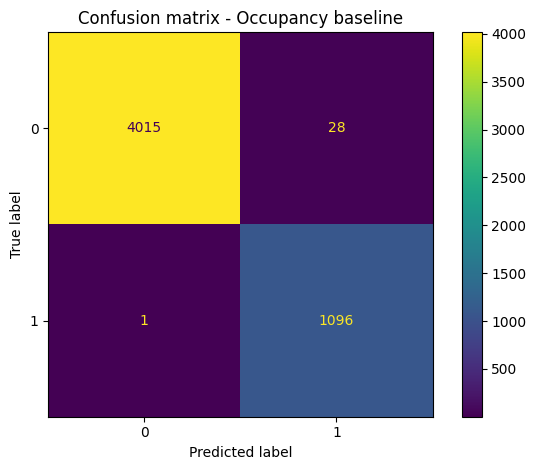

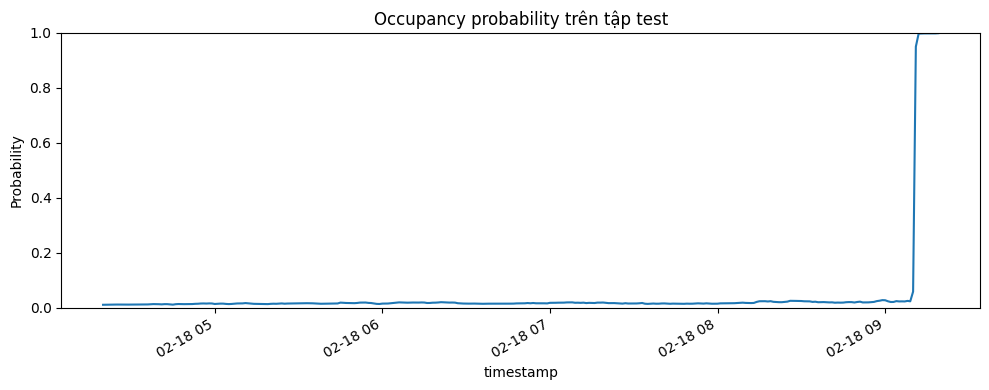

Saved figures to: d:\Ki3_nam3\AIot\lab2_aiot_public_dataset_deploy 2\lab2_aiot_public_dataset_deploy 2\outputs\figures


In [12]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

FIGURES_DIR = PROJECT_ROOT / "outputs" / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)

# 1) CO2 time-series
plt.figure(figsize=(10, 4))
feature_df.tail(600).plot(x="timestamp", y="CO2", legend=False, ax=plt.gca())
plt.title("CO2 theo thời gian")
plt.xlabel("timestamp")
plt.ylabel("CO2 ppm")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "01_co2_time_series.png", dpi=160)
plt.show()

# 2) Confusion matrix
disp = ConfusionMatrixDisplay.from_predictions(test_df["Occupancy"], model.predict(test_df[API_FEATURES]))
disp.ax_.set_title("Confusion matrix - Occupancy baseline")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "02_confusion_matrix.png", dpi=160)
plt.show()

# 3) Occupancy probability
prob = model.predict_proba(test_df[API_FEATURES])[:, 1]
plot_df = test_df.copy().tail(300)
plot_df["occupancy_probability"] = prob[-300:]
plt.figure(figsize=(10, 4))
plot_df.plot(x="timestamp", y="occupancy_probability", legend=False, ax=plt.gca())
plt.title("Occupancy probability trên tập test")
plt.xlabel("timestamp")
plt.ylabel("Probability")
plt.ylim(0, 1)
plt.tight_layout()
plt.savefig(FIGURES_DIR / "03_occupancy_probability.png", dpi=160)
plt.show()

print("Saved figures to:", FIGURES_DIR)

## 12. Kiểm tra hoàn thành phần notebook

Nếu cell này chạy thành công, sinh viên đã hoàn thành phần data preparation + baseline model.

Sau bước này, chuyển sang terminal để deploy:

```bash
uvicorn src.app:app --reload --host 127.0.0.1 --port 8000
```

Sau đó mở terminal thứ hai:

```bash
python src/test_api.py
python src/check_outputs.py
```

In [13]:
from pathlib import Path

required_files = [
    PROJECT_ROOT / "data" / "telemetry_clean.csv",
    PROJECT_ROOT / "data" / "feature_dataset.csv",
    PROJECT_ROOT / "models" / "occupancy_baseline.joblib",
    PROJECT_ROOT / "outputs" / "metrics.json",
    PROJECT_ROOT / "outputs" / "decision_log.csv",
    PROJECT_ROOT / "outputs" / "figures" / "01_co2_time_series.png",
    PROJECT_ROOT / "outputs" / "figures" / "02_confusion_matrix.png",
    PROJECT_ROOT / "outputs" / "figures" / "03_occupancy_probability.png",
]

for path in required_files:
    print("OK " if path.exists() else "MISS", path.relative_to(PROJECT_ROOT))

assert all(path.exists() for path in required_files), "Thiếu file output. Hãy kiểm tra lại các cell phía trên."
assert metrics["f1"] >= 0.75, "F1 thấp bất thường. Hãy kiểm tra dữ liệu hoặc preprocessing."
assert len(decision_log) >= 50, "Decision log quá ít dòng."

print("\nNOTEBOOK PASSED: Có thể chuyển sang bước deploy FastAPI.")

OK  data\telemetry_clean.csv
OK  data\feature_dataset.csv
OK  models\occupancy_baseline.joblib
OK  outputs\metrics.json
OK  outputs\decision_log.csv
OK  outputs\figures\01_co2_time_series.png
OK  outputs\figures\02_confusion_matrix.png
OK  outputs\figures\03_occupancy_probability.png

NOTEBOOK PASSED: Có thể chuyển sang bước deploy FastAPI.
